In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('pre-analysis.csv')

In [3]:
df.head()

,session_date,client_id,traffic_source,device_type,session_duration_seconds,scrolled_down,clicked_download_syllabus
0,2024-01-05,1787846414,Paid Ads,Mobile,8,0,0
1,2024-01-06,5537253173,Direct,Mobile,14,0,0
2,2024-01-05,5298312065,Organic Search,Desktop,15,0,0
3,2024-01-03,5325316860,Organic Search,Mobile,18,0,0
4,2024-01-02,5495394816,Paid Ads,Mobile,4,0,0


In [4]:
# renaming columns to make them easier to work with
df = df.rename(columns={'session_duration_seconds': 'session_sec', 'scrolled_down':'scrolled', 'clicked_download_syllabus':'clicked'})

In [5]:
df.info()
# date is wrong type requires fixing

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   session_date    2000 non-null   str  
 1   client_id       2000 non-null   int64
 2   traffic_source  2000 non-null   str  
 3   device_type     2000 non-null   str  
 4   session_sec     2000 non-null   int64
 5   scrolled        2000 non-null   int64
 6   clicked         2000 non-null   int64
dtypes: int64(4), str(3)
memory usage: 160.2 KB


In [6]:
#new column with dates in correct format
df['date']=pd.to_datetime(df['session_date'])

In [7]:
# additional columns for year and month to make it easier to group by time periods
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [8]:
#sessions less and more then 50 seconds 
df['session_bin'] = pd.cut(
    df['session_sec'], bins=[0, 50, float('inf')], labels=['<50', '50+'])

In [9]:
# short session is 0-18 (median), medium is 18-60 sec (Q2-Q3), long is more than 60 sec (Q3+)
df['session_bin2'] = pd.cut(
    df['session_sec'], bins=[0, 18, 60, float('inf')], labels=['<18', '18-60', '60+'])

In [10]:
df['traffic_type'] = df['traffic_source'].apply(lambda x: 'Paid' if x in ['Paid Ads'] else 'Unpaid')

In [11]:
df.head()

,session_date,client_id,traffic_source,device_type,session_sec,scrolled,clicked,date,year,month,session_bin,session_bin2,traffic_type
0,2024-01-05,1787846414,Paid Ads,Mobile,8,0,0,2024-01-05,2024,1,<50,<18,Paid
1,2024-01-06,5537253173,Direct,Mobile,14,0,0,2024-01-06,2024,1,<50,<18,Unpaid
2,2024-01-05,5298312065,Organic Search,Desktop,15,0,0,2024-01-05,2024,1,<50,<18,Unpaid
3,2024-01-03,5325316860,Organic Search,Mobile,18,0,0,2024-01-03,2024,1,<50,<18,Unpaid
4,2024-01-02,5495394816,Paid Ads,Mobile,4,0,0,2024-01-02,2024,1,<50,<18,Paid


In [12]:
#checking unique values
df[['client_id', 'traffic_source', 'device_type', 'clicked', 'scrolled']].nunique()

client_id         2000
traffic_source       3
device_type          2
clicked              2
scrolled             2
dtype: int64

In [13]:
df.describe()



,client_id,session_sec,scrolled,clicked,date,year,month
count,2.000000e+03,2000.000000,2000.00000,2000.000000,2000,2000.0,2000.000000
mean,5.481822e+09,33.317000,0.25300,0.097000,2024-01-28 15:03:36,2024.0,1.453000
min,1.001902e+09,1.000000,0.00000,0.000000,2024-01-01 00:00:00,2024.0,1.000000
25%,3.210014e+09,11.000000,0.00000,0.000000,2024-01-14 18:00:00,2024.0,1.000000
50%,5.481259e+09,18.000000,0.00000,0.000000,2024-01-28 12:00:00,2024.0,1.000000
75%,7.741653e+09,67.250000,1.00000,0.000000,2024-02-11 06:00:00,2024.0,2.000000
max,9.998007e+09,121.000000,1.00000,1.000000,2024-02-25 00:00:00,2024.0,2.000000
std,2.604604e+09,33.600357,0.43484,0.296032,NaN,0.0,0.497911



**clicked** mean 9.7%  
**scrolled** mean 25,3%  
**session duration** is right skewed 
* mean 33.3 sec
* median 18 sec

In [14]:
df['month'].value_counts()

#traffic per month is ~950 people

month
1    1094
2     906
Name: count, dtype: int64

In [15]:
df['device_type'].value_counts(normalize=True)*100
# 60% of users are coming from mobile and the rest is desktop ~40%

device_type
Mobile     60.15
Desktop    39.85
Name: proportion, dtype: float64

In [16]:
# correlation between session duration and scroll/click
cor = df[['session_sec', 'scrolled', 'clicked']].corr()
cor

,session_sec,scrolled,clicked
session_sec,1.000000,0.970715,0.179620
scrolled,0.970715,1.000000,0.186217
clicked,0.179620,0.186217,1.000000


<Axes: >

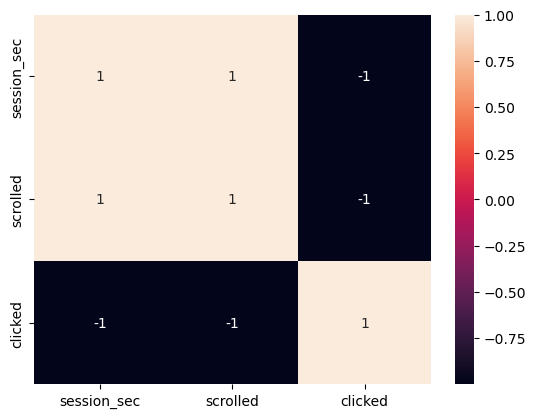

In [17]:
sns.heatmap(cor.corr(), annot=True)

high correlation between session length and scroll rates

In [18]:
# click and scroll rate on devices
df.groupby('device_type')[['scrolled', 'clicked']].mean()*100

,scrolled,clicked
device_type,,
Desktop,16.060226,9.284818
Mobile,31.421446,9.975062


In [19]:
df.groupby(['device_type', 'clicked'])['scrolled'].mean()*100

device_type  clicked
Desktop      0          13.969571
             1          36.486486
Mobile       0          28.439520
             1          58.333333
Name: scrolled, dtype: float64

**Desctop users scroll rate**
36.5% for those who clicked
~14% for those who did not click

**Mobile users scroll rate**
58.3% for those who clicked
28.5% for those who did not click

the engamement rates on Mobile looks way higher this may be connected with UX/UI since users used to scroll on mobile devices espacially on phones


In [20]:
df.pivot_table(index='device_type', columns='clicked', values='scrolled', aggfunc='mean')*100

clicked,0,1
device_type,,
Desktop,13.969571,36.486486
Mobile,28.439520,58.333333


In [21]:
df['session_bin'].value_counts(normalize=True)*100

session_bin
<50    74.7
50+    25.3
Name: proportion, dtype: float64

<Axes: xlabel='session_bin', ylabel='count'>

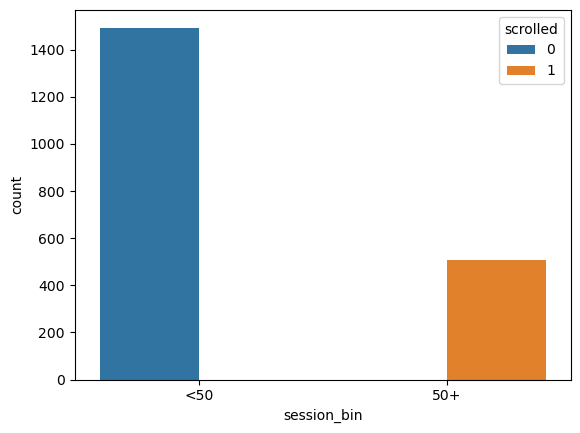

In [22]:
# session duration countplot with hue for scroll
sns.countplot(data = df, x="session_bin",  hue = "scrolled")

In [23]:
# click and scroll rate based on traffic
df.groupby('traffic_type')[['scrolled', 'clicked']].mean()*100


,scrolled,clicked
traffic_type,,
Paid,25.806452,9.429280
Unpaid,24.958124,9.882747



**Unpaid traffic** has scroll ~24.9 and click ~9.5.     
**Paid traffic** has scroll ~25.8 and click ~9.4.   

In [24]:
# click and scroll rate based on session duration
table = df.groupby('session_bin')[['scrolled', 'clicked']].mean()*100
table 

,scrolled,clicked
session_bin,,
<50,0.0,6.492637
50+,100.0,19.169960


In [25]:
# traffic and device  
device_traffic = df.groupby('device_type')['traffic_type'].value_counts(normalize=True)*100
device_traffic.unstack(fill_value=0)

traffic_type,Paid,Unpaid
device_type,,
Desktop,39.523212,60.476788
Mobile,40.814630,59.185370


both mobile and desktop around 40% of traffic is coming from ads   
which makes me belive the engamement should be higher then 25%  
because people coming from ads usually targeted and should have more interest in exploration of information

In [26]:
session_traffic = df.groupby('session_bin')['traffic_type'].value_counts(normalize=True)*100
session_traffic.unstack(fill_value=0)

traffic_type,Paid,Unpaid
session_bin,,
<50,40.026774,59.973226
50+,41.106719,58.893281


similar in session length
roughly only around 40% traffic is from paid ads for both short and long sessions  
with almost 60% of unpaid traffic
this requires  flagging to marketiong department

In [27]:

session_traffic = df.groupby(['session_bin2', 'traffic_type'])['scrolled'].value_counts(normalize=True)*100
session_traffic.unstack(fill_value=0)



scrolled                            0           1
session_bin2 traffic_type                        
<18          Paid          100.000000    0.000000
             Unpaid        100.000000    0.000000
18-60        Paid          100.000000    0.000000
             Unpaid         99.621212    0.378788
60+          Paid            0.000000  100.000000
             Unpaid          0.000000  100.000000

In [31]:

session_traffic2 = df.groupby(['session_bin', 'traffic_type'])[['scrolled', 'clicked']].value_counts(normalize=True)*100
session_traffic2.unstack(fill_value=0)

clicked                                    0          1
session_bin traffic_type scrolled                      
<50         Paid         0         93.812709   6.187291
            Unpaid       0         93.303571   6.696429
50+         Paid         1         81.250000  18.750000
            Unpaid       1         80.536913  19.463087

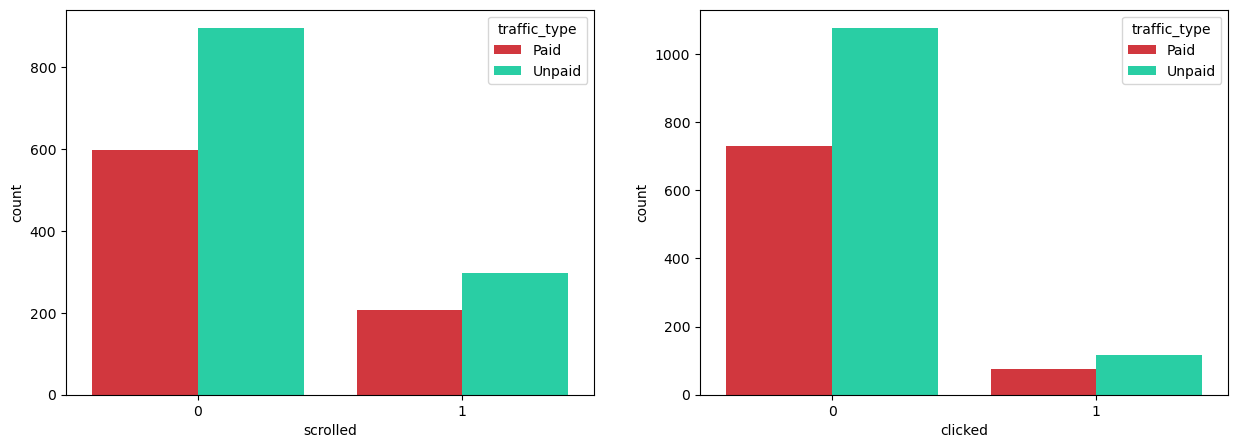

In [28]:
# rate scroll for session duration with hue for trafic type
fig, axes = plt.subplots(1, 2, figsize = (15,5))
palette = ["#EB1D27","#0EE9B2"]
sns.countplot(data= df, x= "scrolled", hue ="traffic_type", palette = palette, ax= axes[0])
sns.countplot(data= df, x= "clicked", hue ="traffic_type", palette = palette, ax= axes[1])
plt.show()